<a href="https://colab.research.google.com/github/raneemmsbri/spam-detection-/blob/main/spam_detection_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
drive.mount('/content/drive')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import os
os.chdir("/content/drive/MyDrive/spam emails")
!pwd


/content/drive/MyDrive/spam emails


In [ ]:
#!unzip "/content/drive/MyDrive/spam emails/archive (2).zip"\
#d "/content/drive/MyDrive/spam emails"

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from bs4 import BeautifulSoup
from wordcloud import WordCloud
import nltk
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.model_selection import train_test_split





In [ ]:
from  sklearn.preprocessing import LabelEncoder
import string

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB  # Assuming you mean MultinomialNB for Naive Bayes
from sklearn.svm import SVC  # Support Vector Classification
from sklearn.ensemble import BaggingClassifier, RandomForestClassifier, AdaBoostClassifier, GradientBoostingClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

#CounterVectorizer Convert the text into matrics
from sklearn.feature_extraction.text import CountVectorizer


In [ ]:
#!unzip "/content/drive/MyDrive/spam emails/archive (2).zip"\
#d "/content/drive/MyDrive/spam emails"

In [ ]:
dataset=pd.read_csv("/content/drive/MyDrive/spam emails/spam mail.csv",encoding='latin-1')

dataset.head()

,Category,Masseges
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


In [ ]:
dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5572 entries, 0 to 5571
Data columns (total 2 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   Category  5572 non-null   object
 1   Masseges  5572 non-null   object
dtypes: object(2)
memory usage: 87.2+ KB


In [ ]:
dataset.duplicated().sum()


np.int64(403)

In [ ]:
dataset.drop_duplicates(inplace=True)
dataset.duplicated().sum()


np.int64(0)

In [ ]:
dataset.describe()

,Category,Masseges
count,5169,5169
unique,2,5169
top,ham,Rofl. Its true to its name
freq,4516,1


In [ ]:
dataset["Category"].value_counts()


,count
Category,
ham,4516
spam,653


In [ ]:
dataset.isnull().sum().sort_values(ascending=False)

,0
Category,0
Masseges,0


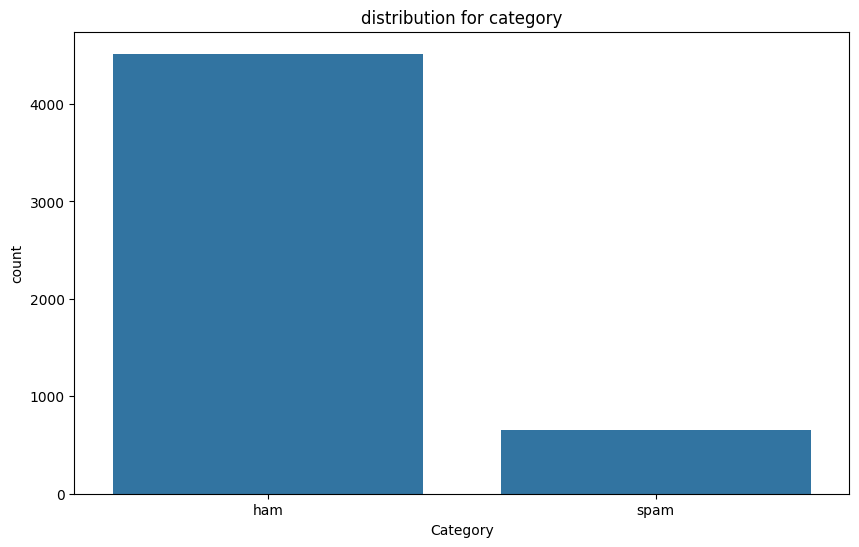

In [ ]:
plt.figure(figsize=(10,6))
sns.countplot(x="Category",data=dataset)
plt.title("distribution for category")
plt.show()

In [ ]:
Encoder=LabelEncoder()
dataset["Category"]=Encoder.fit_transform(dataset["Category"])
dataset.head()

,Category,Masseges
0,0,"Go until jurong point, crazy.. Available only ..."
1,0,Ok lar... Joking wif u oni...
2,1,Free entry in 2 a wkly comp to win FA Cup fina...
3,0,U dun say so early hor... U c already then say...
4,0,"Nah I don't think he goes to usf, he lives aro..."


In [ ]:
dataset["Masseges"]=dataset["Masseges"].str.lower()
dataset.head()

,Category,Masseges
0,0,"go until jurong point, crazy.. available only ..."
1,0,ok lar... joking wif u oni...
2,1,free entry in 2 a wkly comp to win fa cup fina...
3,0,u dun say so early hor... u c already then say...
4,0,"nah i don't think he goes to usf, he lives aro..."


In [ ]:
dataset['Masseges'] = dataset['Masseges'].str.replace(r'[^\w\s]', '', regex=True)


In [ ]:
def remove_html(text):
  soup=BeautifulSoup(text,'html.parser')
  return soup.get_text()



dataset['Masseges']=dataset['Masseges'].apply(remove_html)

In [ ]:
dataset['Masseges']=dataset['Masseges'].str.strip()

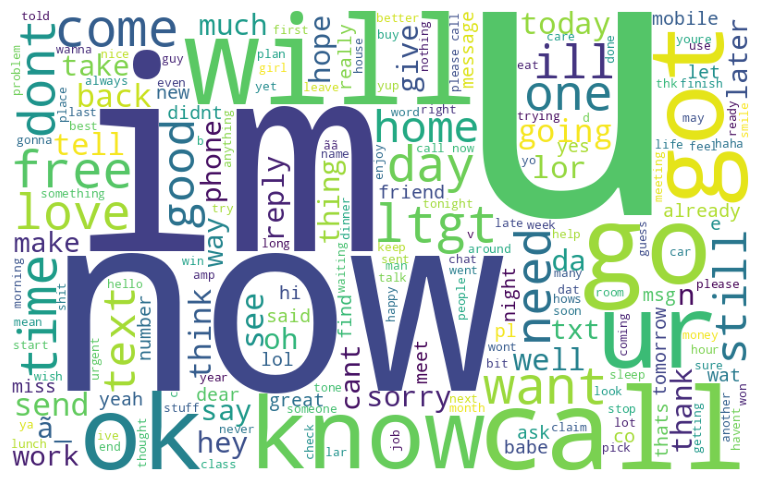

In [ ]:
text=' '.join(dataset["Masseges"])
wordcloude=WordCloud(width=800,height=500,background_color='White').generate(text)
plt.figure(figsize=(10,6))
plt.imshow(wordcloude)
plt.axis("off")
plt.show()



In [ ]:
nltk.download('stopwords')


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [ ]:

stop_words = set(stopwords.words('english'))


# Function to remove stop words from text
def remove_stopwords(text):
    words = text.split()
    filtered_words = [word for word in words if word.lower() not in stop_words]
    return ' '.join(filtered_words)

# Apply remove_stopwords function to 'Text' column
dataset['Masseges'] = dataset['Masseges'].apply(remove_stopwords)

In [ ]:
porter_stemmer=PorterStemmer()

dataset["Masseges"]=dataset["Masseges"].apply( lambda x: ' '.join([porter_stemmer.stem(word) for word in x.split()]))



In [ ]:
cv = CountVectorizer()

# Fitting CountVectorizer on X
X = cv.fit_transform(dataset['Masseges']).toarray()
y = dataset['Category']

In [ ]:
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.25)


In [ ]:
bc = BaggingClassifier(n_estimators=50, random_state=42)
gbdt = GradientBoostingClassifier(n_estimators=50, random_state=42)
xgb = XGBClassifier(n_estimators=50, random_state=42)
svc = SVC(kernel="sigmoid", gamma=1.0)
mnb = MultinomialNB()
dtc = DecisionTreeClassifier(max_depth=10)
lrc = LogisticRegression(solver='liblinear', penalty='l1')
rfc = RandomForestClassifier(n_estimators=50, random_state=42)
abc = AdaBoostClassifier(n_estimators=50, random_state=42)


models = {
    'BGC': bc,
    'GBDT': gbdt,
    'xgb': xgb,
    'SVC': svc,
    'NB': mnb,
    'DT': dtc,
    'LR': lrc,
    'RF': rfc,
    'Adaboost': abc
}

def train_classifier(model, X_train, y_train, X_test, y_test):
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall=recall_score(y_test, y_pred)

    return accuracy, precision,recall

In [ ]:
accuracy_scores = []
precision_scores = []
recall_scores_list = []

for name, model in models.items():
    current_accuracy, current_precision, recall = train_classifier(
        model, X_train, y_train, X_test, y_test
    )

    rounded_accuracy = round(current_accuracy, 2)
    rounded_precision = round(current_precision, 2)
    rounded_recall = round(recall, 2)

    print()
    print("For:", name)
    print("Accuracy:", rounded_accuracy)
    print("Precision:", rounded_precision)
    print("Recall:", rounded_recall)

    accuracy_scores.append(rounded_accuracy)
    precision_scores.append(rounded_precision)
    recall_scores_list.append(rounded_recall)



For: BGC
Accuracy: 0.96
Precision: 0.97
Recall: 0.73

For: GBDT
Accuracy: 0.95
Precision: 0.97
Recall: 0.65

For: xgb
Accuracy: 0.97
Precision: 0.98
Recall: 0.77

For: SVC
Accuracy: 0.93
Precision: 0.76
Recall: 0.7

For: NB
Accuracy: 0.97
Precision: 0.87
Recall: 0.94

For: DT
Accuracy: 0.94
Precision: 0.94
Recall: 0.59

For: LR
Accuracy: 0.97
Precision: 0.96
Recall: 0.84

For: RF
Accuracy: 0.97
Precision: 0.99
Recall: 0.73

For: Adaboost
Accuracy: 0.92
Precision: 0.91
Recall: 0.44


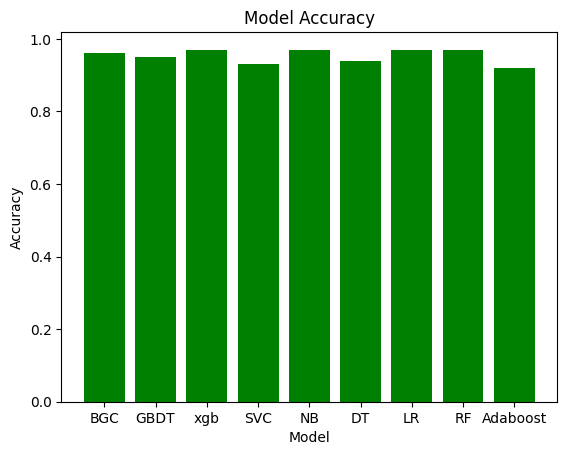

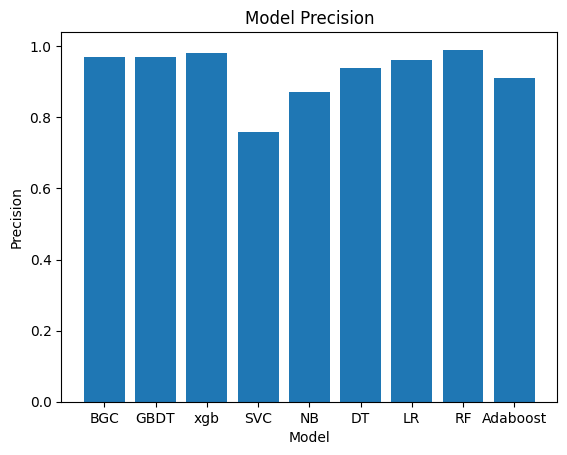

In [ ]:
plt.bar(x=['BGC', 'GBDT', 'xgb', 'SVC', 'NB', 'DT', 'LR', 'RF', 'Adaboost'], height=accuracy_scores, color='green')
plt.xlabel('Model')
plt.ylabel('Accuracy')
plt.title('Model Accuracy')

# Plot the precision scores
plt.figure()
plt.bar(x=['BGC', 'GBDT', 'xgb', 'SVC', 'NB', 'DT', 'LR', 'RF', 'Adaboost'], height=precision_scores)
plt.xlabel('Model')
plt.ylabel('Precision')
plt.title('Model Precision')

plt.show()

In [ ]:
import pickle
pickle.dump(mnb, open('model.pkl', 'wb'))